# Wine Quality Prediction

## Regression Task

Predictive models that estimate the quality of wine based on its chemical properties.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from xgboost import  XGBRegressor


import warnings
warnings.filterwarnings('ignore')

## Importing and Reading Dataset

In [2]:
wine = pd.read_csv('../Dataset/winequalityN.csv')

wine.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Feature Engineering

In [3]:
wine['acid_ratio'] = wine['fixed acidity'] / (wine['volatile acidity'])
wine['sulfur_ratio'] = wine['free sulfur dioxide'] / (wine['total sulfur dioxide'])
wine['alcohol_density'] = wine['alcohol'] * wine['density']
wine['total_acidity'] = wine['fixed acidity'] + wine['volatile acidity'] + wine['citric acid']
wine['alcohol_sugar'] = wine['alcohol'] / (wine['residual sugar'])
wine['salt_acid'] = wine['chlorides'] * wine['fixed acidity']
wine['pH_acidity'] = wine['pH'] * wine['fixed acidity']

## Summary Statistics

In [4]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acid_ratio,sulfur_ratio,alcohol_density,total_acidity,alcohol_sugar,salt_acid,pH_acidity
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000,6480.000000,6497.000000,6497.000000,6477.000000,6495.000000,6485.000000,6480.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378,25.345189,0.286768,10.433703,7.875562,3.935281,0.418052,23.173676
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255,10.728309,0.124645,1.163828,1.389087,2.966772,0.311766,4.003321
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,4.807692,0.022727,7.946560,4.130000,0.177812,0.045000,13.923000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,17.708791,0.202073,9.458200,7.020000,1.230327,0.254400,20.601000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,24.000000,0.269767,10.257770,7.600000,3.531250,0.325600,22.360000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,31.111111,0.348837,11.214233,8.380000,5.882353,0.473600,24.705750
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,90.000000,0.857143,14.864240,17.045000,17.666667,5.612000,47.382000


## Checking For Missing Values

In [5]:
wine.isnull().sum().sort_values(ascending=False)

total_acidity           20
acid_ratio              17
pH_acidity              17
salt_acid               12
fixed acidity           10
pH                       9
volatile acidity         8
sulphates                4
citric acid              3
alcohol_sugar            2
residual sugar           2
chlorides                2
type                     0
density                  0
free sulfur dioxide      0
total sulfur dioxide     0
alcohol                  0
alcohol_density          0
quality                  0
sulfur_ratio             0
dtype: int64

## Handling Missing Values

In [6]:
imputer = SimpleImputer(strategy='median')

missing_cols = ['fixed acidity', 'pH', 'volatile acidity', 'sulphates', 'citric acid', 'chlorides', 'residual sugar', 'acid_ratio', 'total_acidity', 'pH_acidity', 'salt_acid', 'alcohol_sugar']

for cols in missing_cols:
    wine[cols] = imputer.fit_transform(wine[[cols]])

## Confirm Handling Missing Values 

In [7]:
wine.isnull().sum().sort_values(ascending=False)

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
acid_ratio              0
sulfur_ratio            0
alcohol_density         0
total_acidity           0
alcohol_sugar           0
salt_acid               0
pH_acidity              0
dtype: int64

## Handling Outliers

In [8]:
q1 = wine.select_dtypes(include=[np.number]).quantile(0.25)
q3 = wine.select_dtypes(include=[np.number]).quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print('Lower bound: \n', lower_bound)
print('Upper bound: \n', upper_bound)


Lower bound: 
 fixed acidity            4.450000
volatile acidity        -0.025000
citric acid              0.040000
residual sugar          -7.650000
chlorides               -0.002500
free sulfur dioxide    -19.000000
total sulfur dioxide   -41.500000
density                  0.985365
pH                       2.795000
sulphates                0.175000
alcohol                  6.800000
quality                  3.500000
acid_ratio              -2.293233
sulfur_ratio            -0.018074
alcohol_density          6.824150
total_acidity            4.980000
alcohol_sugar           -5.746606
salt_acid               -0.073150
pH_acidity              14.484000
dtype: float64
Upper bound: 
 fixed acidity             9.650000
volatile acidity          0.655000
citric acid               0.600000
residual sugar           17.550000
chlorides                 0.105500
free sulfur dioxide      77.000000
total sulfur dioxide    274.500000
density                   1.003965
pH                        3.6

In [9]:
for col in wine.select_dtypes(include=[np.number]):
    mask = (wine[col] < lower_bound[col]) | (wine[col] > upper_bound[col])
    count = mask.sum()
    if count > 0:
        print(f'{col}: {count} outliers | '
              f'bounds=[{lower_bound[col]:.2f}, {upper_bound[col]:.2f}] | '
              f'actual min={wine[col].min():.2f}, max={wine[col].max():.2f}')


fixed acidity: 357 outliers | bounds=[4.45, 9.65] | actual min=3.80, max=15.90
volatile acidity: 376 outliers | bounds=[-0.02, 0.66] | actual min=0.08, max=1.58
citric acid: 508 outliers | bounds=[0.04, 0.60] | actual min=0.00, max=1.66
residual sugar: 118 outliers | bounds=[-7.65, 17.55] | actual min=0.60, max=65.80
chlorides: 286 outliers | bounds=[-0.00, 0.11] | actual min=0.01, max=0.61
free sulfur dioxide: 62 outliers | bounds=[-19.00, 77.00] | actual min=1.00, max=289.00
total sulfur dioxide: 10 outliers | bounds=[-41.50, 274.50] | actual min=6.00, max=440.00
density: 3 outliers | bounds=[0.99, 1.00] | actual min=0.99, max=1.04
pH: 73 outliers | bounds=[2.79, 3.63] | actual min=2.72, max=4.01
sulphates: 191 outliers | bounds=[0.17, 0.85] | actual min=0.22, max=2.00
alcohol: 3 outliers | bounds=[6.80, 14.00] | actual min=8.00, max=14.90
quality: 228 outliers | bounds=[3.50, 7.50] | actual min=3.00, max=9.00
acid_ratio: 143 outliers | bounds=[-2.29, 51.06] | actual min=4.81, max=90

## Visualizing the outliers

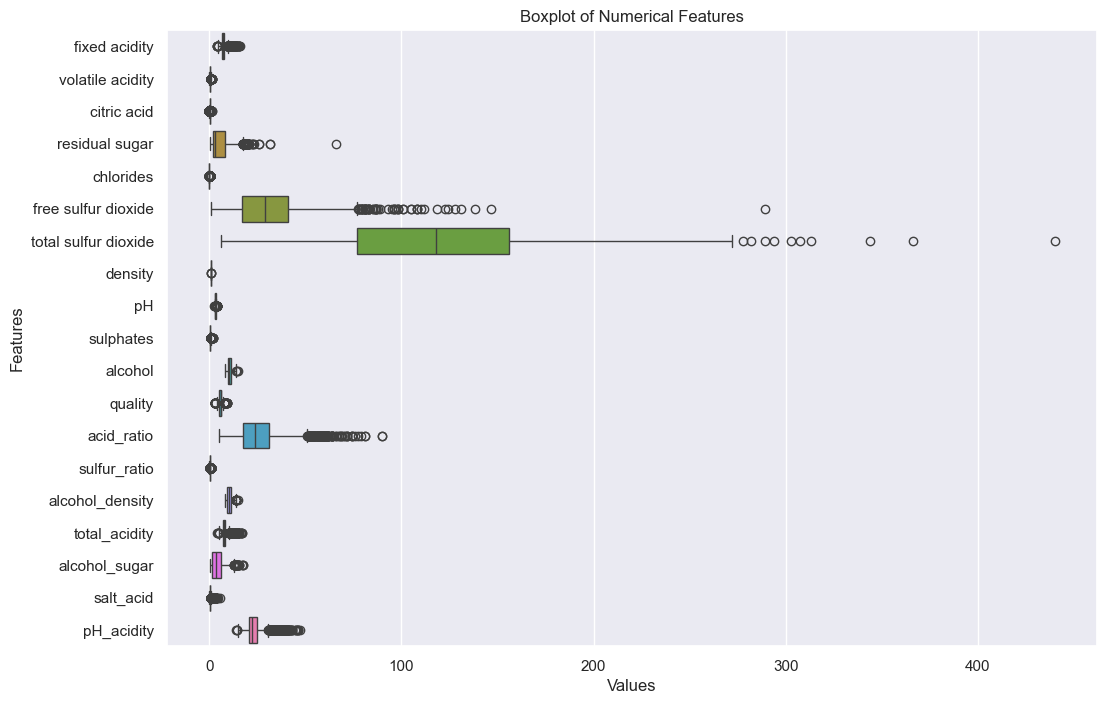

In [10]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=wine.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

##  `Winsorization` Replacing outliers with boundary values

In [11]:
for col in wine.select_dtypes(include=[np.number]):
    q1 = wine[col].quantile(0.25)
    q3 = wine[col].quantile(0.75)
    IQR = q3 -q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    wine[col] = wine[col].clip(lower_bound, upper_bound)

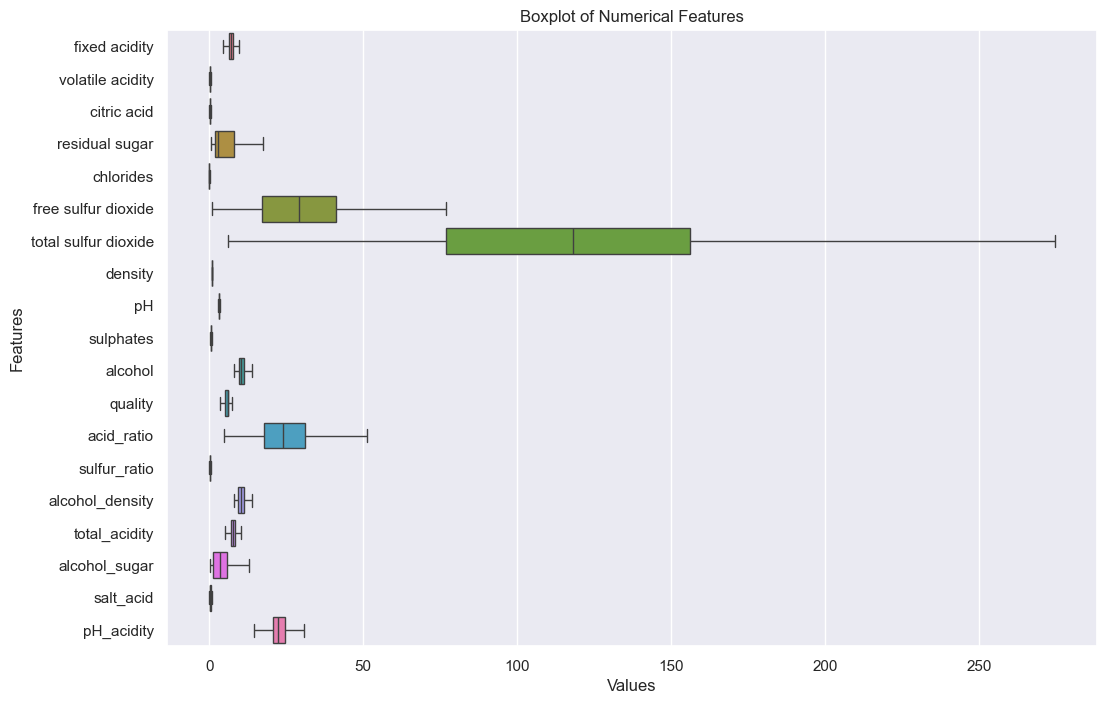

In [12]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=wine.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

## Data Visualization

#### `Quality` by Wine type

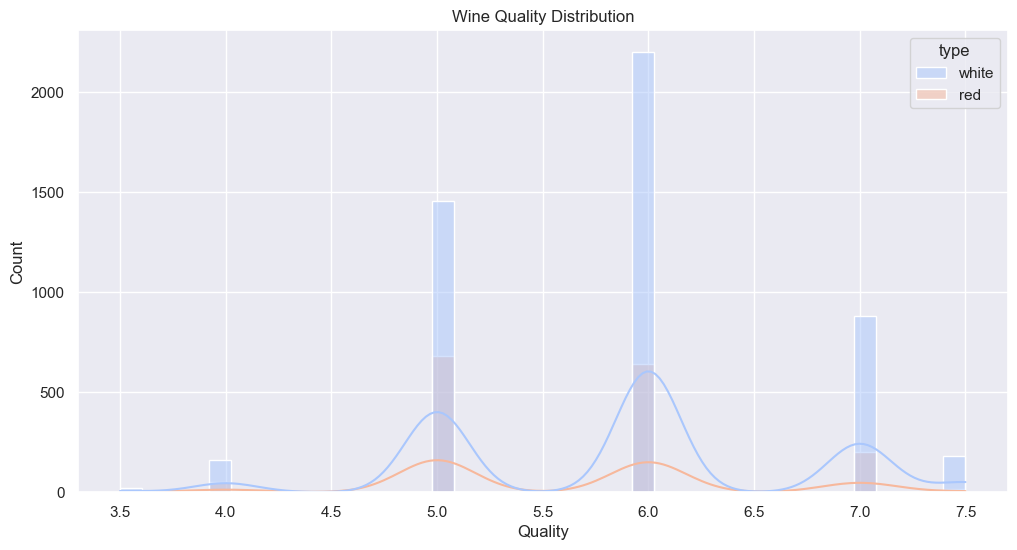

In [13]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'quality', kde=True, palette='coolwarm', hue='type')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

#### `pH` Acidity Level by Wine type

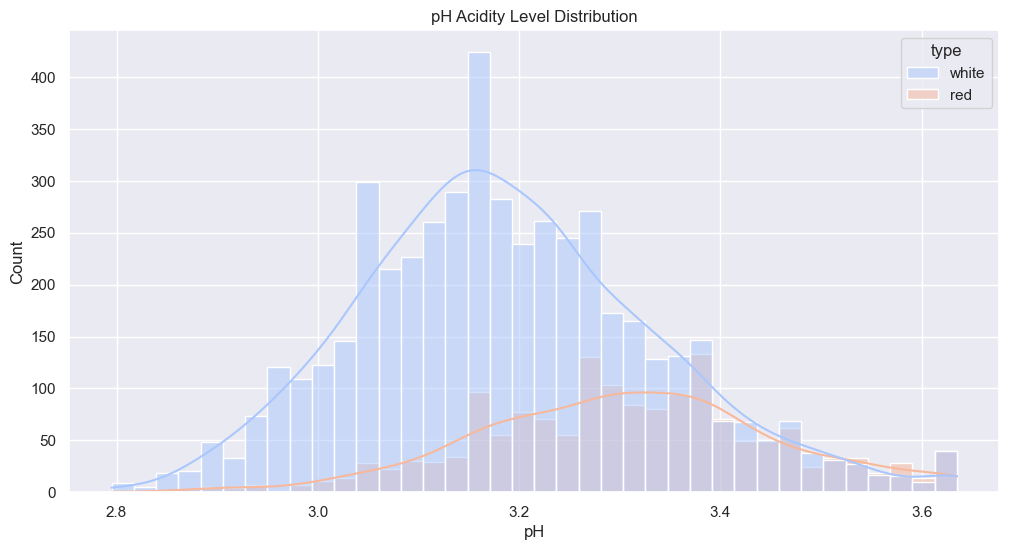

In [14]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'pH', kde=True, palette='coolwarm', hue='type')
plt.title('pH Acidity Level Distribution')
plt.xlabel('pH')
plt.ylabel('Count')
plt.show()

#### `Alcohol` Percentage by Wine type

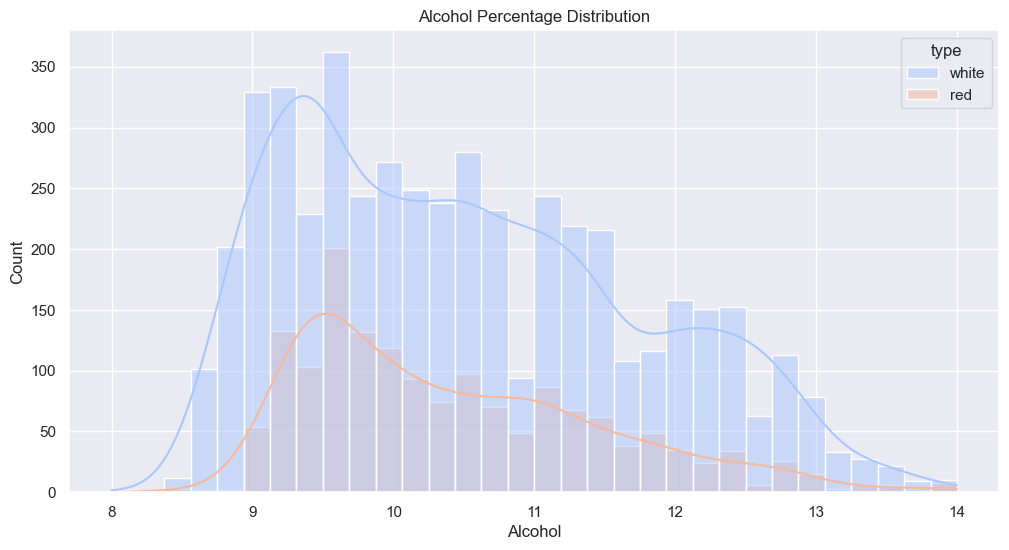

In [15]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'alcohol', kde=True, palette='coolwarm', hue='type')
plt.title('Alcohol Percentage Distribution')
plt.xlabel('Alcohol')
plt.ylabel('Count')
plt.show()

#### `Fixed Acidity` Level by Wine type

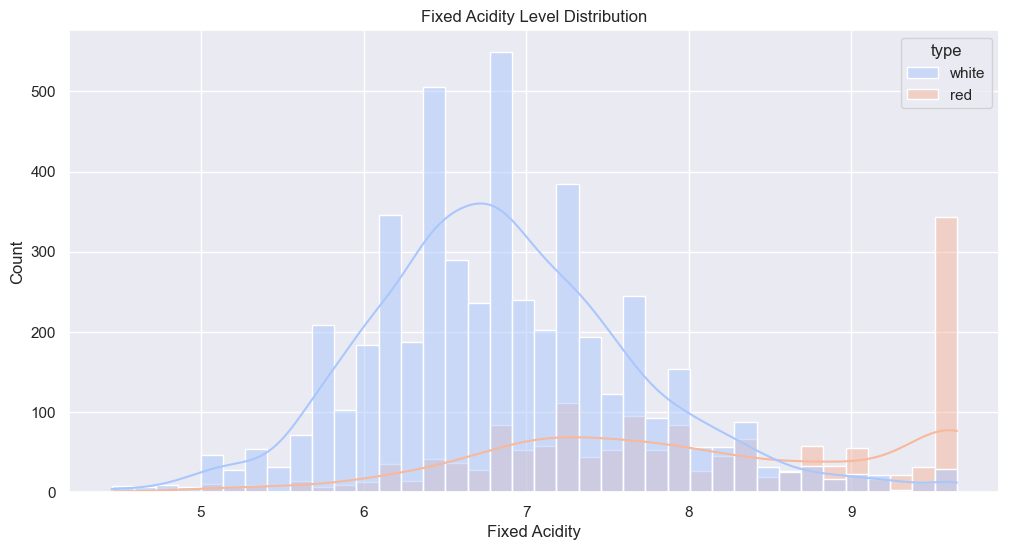

In [16]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'fixed acidity', kde=True, palette='coolwarm', hue='type')
plt.title('Fixed Acidity Level Distribution')
plt.xlabel('Fixed Acidity')
plt.ylabel('Count')
plt.show()

`Volatile Acidity` by Wine type

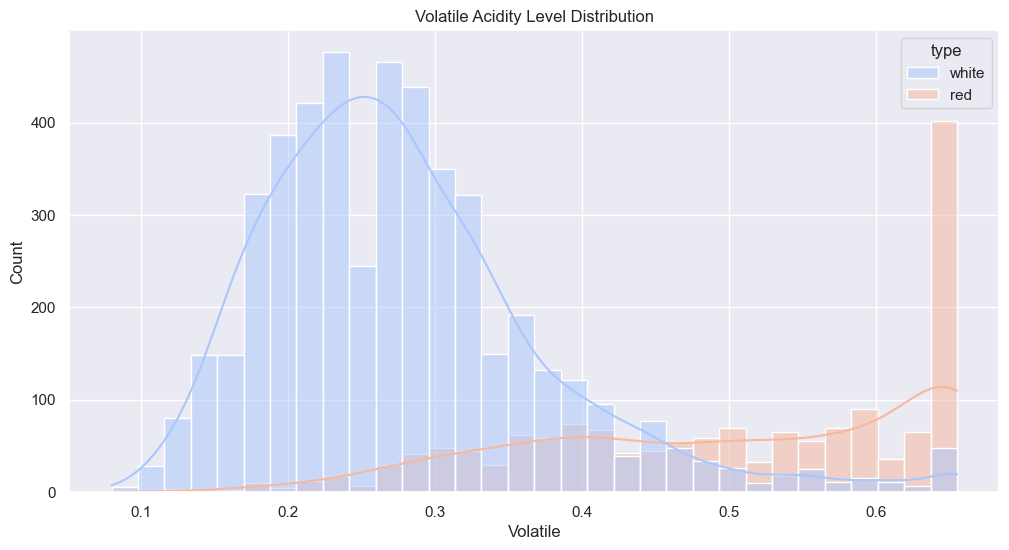

In [17]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'volatile acidity', kde=True, palette='coolwarm', hue='type')
plt.title('Volatile Acidity Level Distribution')
plt.xlabel('Volatile')
plt.ylabel('Count')
plt.show()

#### `Citric Acid` by wine type

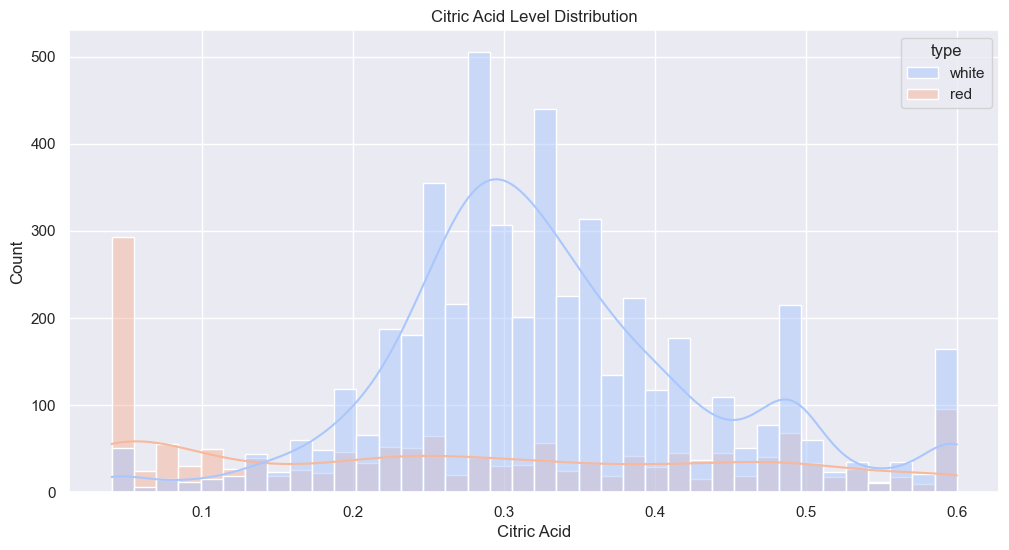

In [18]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'citric acid', kde=True, palette='coolwarm', hue='type')
plt.title('Citric Acid Level Distribution')
plt.xlabel('Citric Acid')
plt.ylabel('Count')
plt.show()

#### `Residual Sugar` Level by Wine type

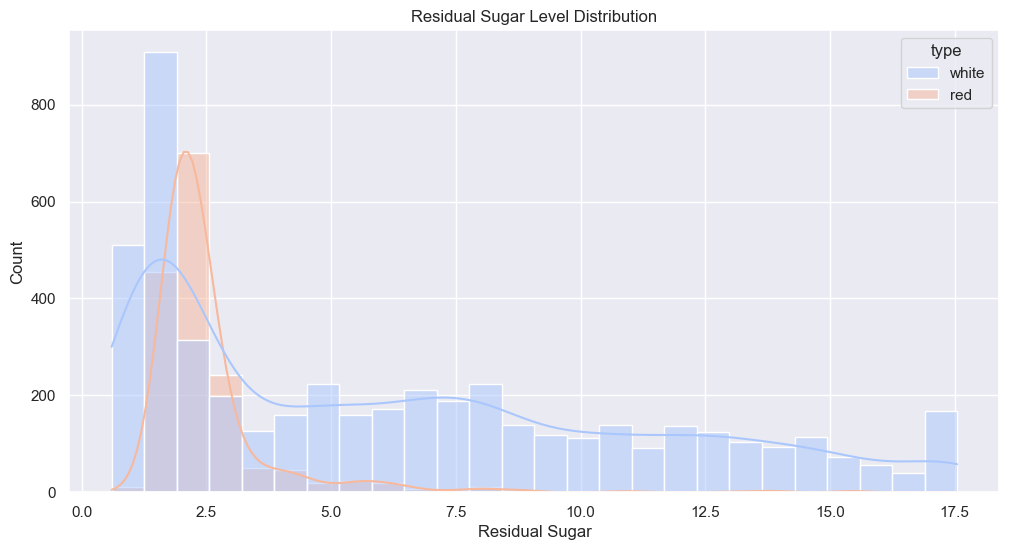

In [19]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'residual sugar', kde=True, palette='coolwarm', hue='type')
plt.title('Residual Sugar Level Distribution')
plt.xlabel('Residual Sugar')
plt.ylabel('Count')
plt.show()

#### `Chlorides` Level by Wine type

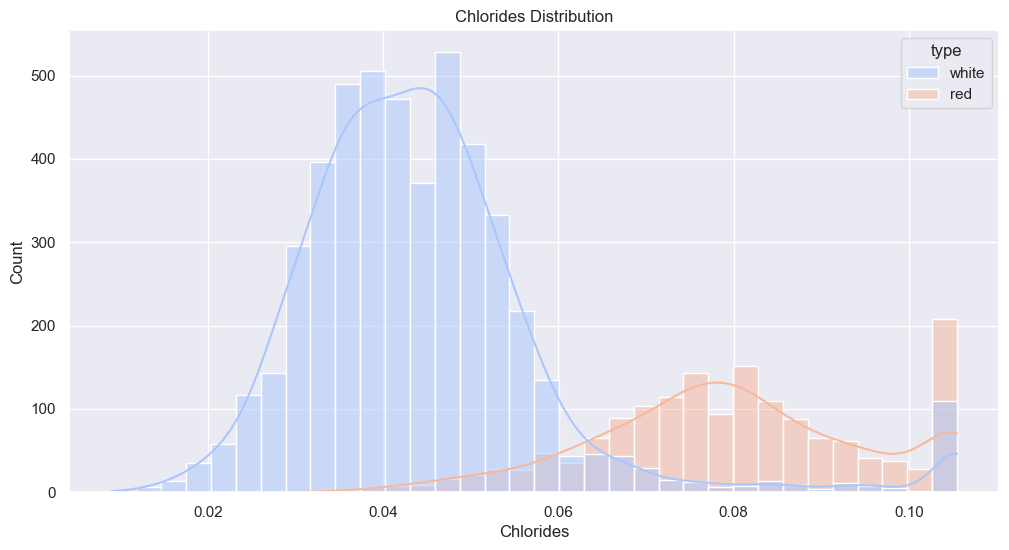

In [20]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'chlorides', kde=True, palette='coolwarm', hue='type')
plt.title('Chlorides Distribution')
plt.xlabel('Chlorides')
plt.ylabel('Count')
plt.show()

#### `Free Sulfur Dioxide` by Wine type

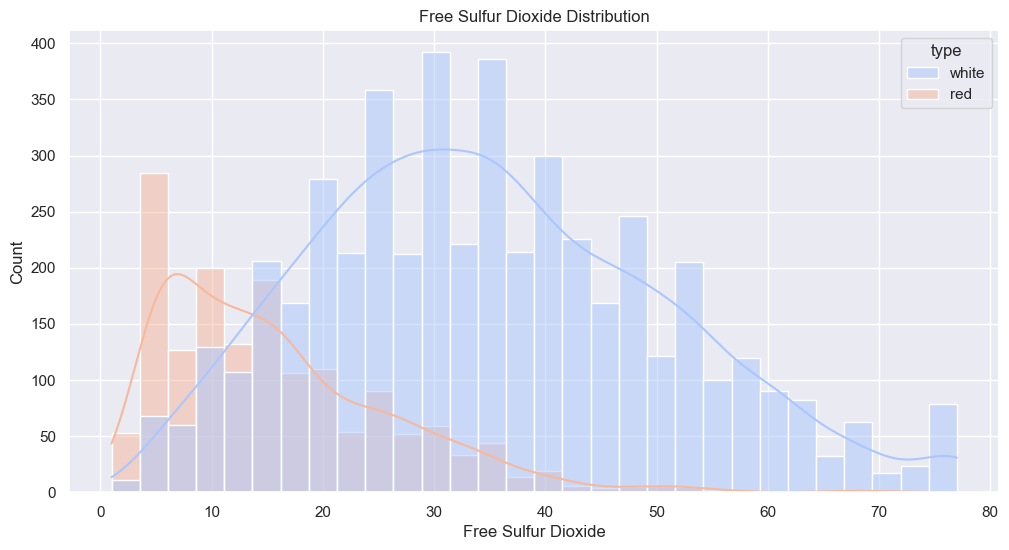

In [21]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'free sulfur dioxide', kde=True, palette='coolwarm', hue='type')
plt.title('Free Sulfur Dioxide Distribution')
plt.xlabel('Free Sulfur Dioxide')
plt.ylabel('Count')
plt.show()

#### `Total Sulfur Dioxide` by Wine type

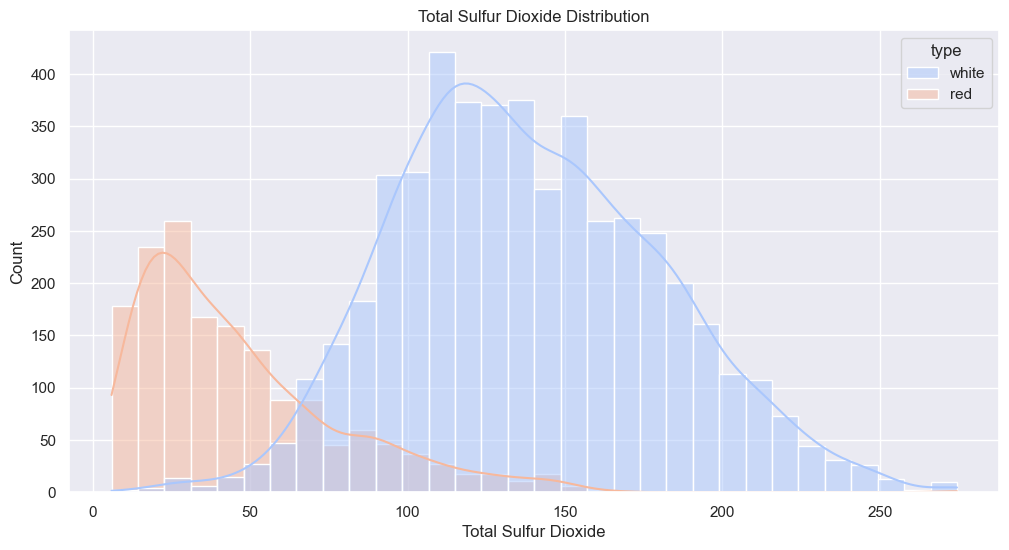

In [22]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'total sulfur dioxide', kde=True, palette='coolwarm', hue='type')
plt.title('Total Sulfur Dioxide Distribution')
plt.xlabel('Total Sulfur Dioxide')
plt.ylabel('Count')
plt.show()

#### `Sulphates` by Wine type

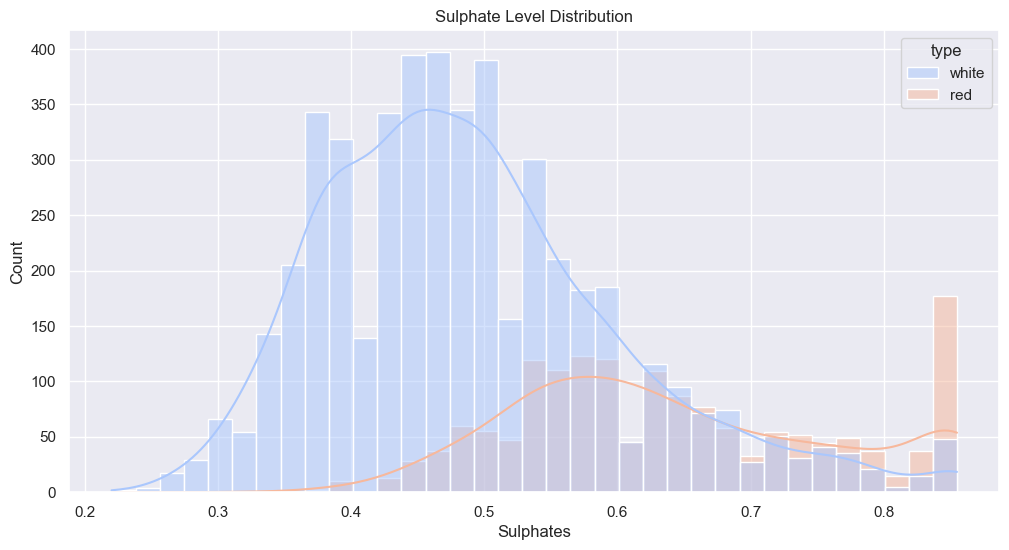

In [23]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'sulphates', kde=True, palette='coolwarm', hue='type')
plt.title('Sulphate Level Distribution')
plt.xlabel('Sulphates')
plt.ylabel('Count')
plt.show()

#### `Density` Level Distribution

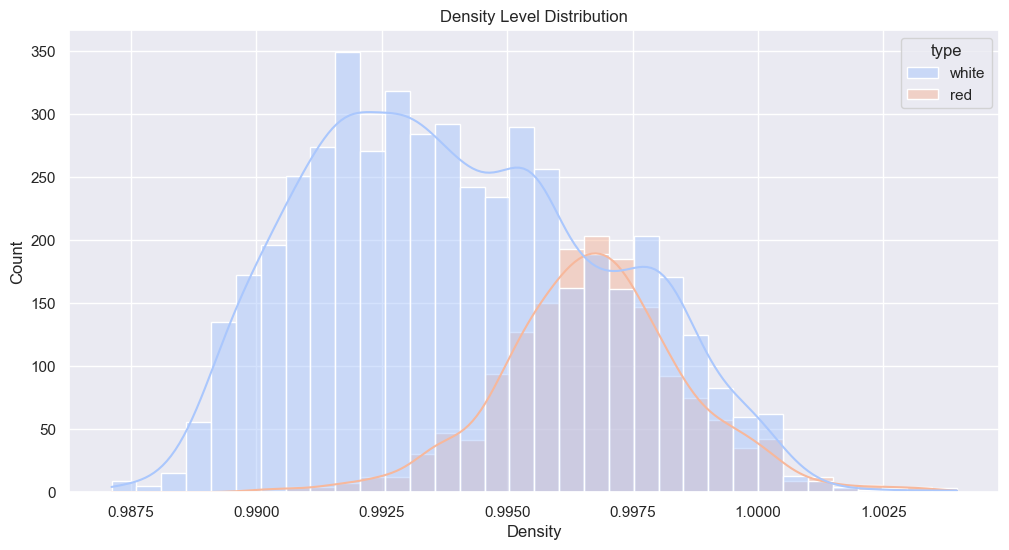

In [24]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'density', kde=True, palette='coolwarm', hue='type')
plt.title('Density Level Distribution')
plt.xlabel('Density')
plt.ylabel('Count')
plt.show()

## Handling Categorical Column

Encoding wine `type` column using OneHotEncoder

In [25]:
wine = pd.get_dummies(wine, columns=['type'], dtype=int)

In [26]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,...,quality,acid_ratio,sulfur_ratio,alcohol_density,total_acidity,alcohol_sugar,salt_acid,pH_acidity,type_red,type_white
0,7.0,0.27,0.36,17.55,0.045,45.0,170.0,1.0010,3.00,0.45,...,6.0,25.925926,0.264706,8.80880,7.63,0.425121,0.3150,21.000,0,1
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,...,6.0,21.000000,0.106061,9.44300,6.94,5.937500,0.3087,20.790,0,1
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,...,6.0,28.928571,0.309278,10.05051,8.78,1.463768,0.4050,26.406,0,1
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,...,6.0,31.304348,0.252688,9.85644,7.75,1.164706,0.4176,22.968,0,1
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,...,6.0,31.304348,0.252688,9.85644,7.75,1.164706,0.4176,22.968,0,1


#### `Correlation` Heatmap

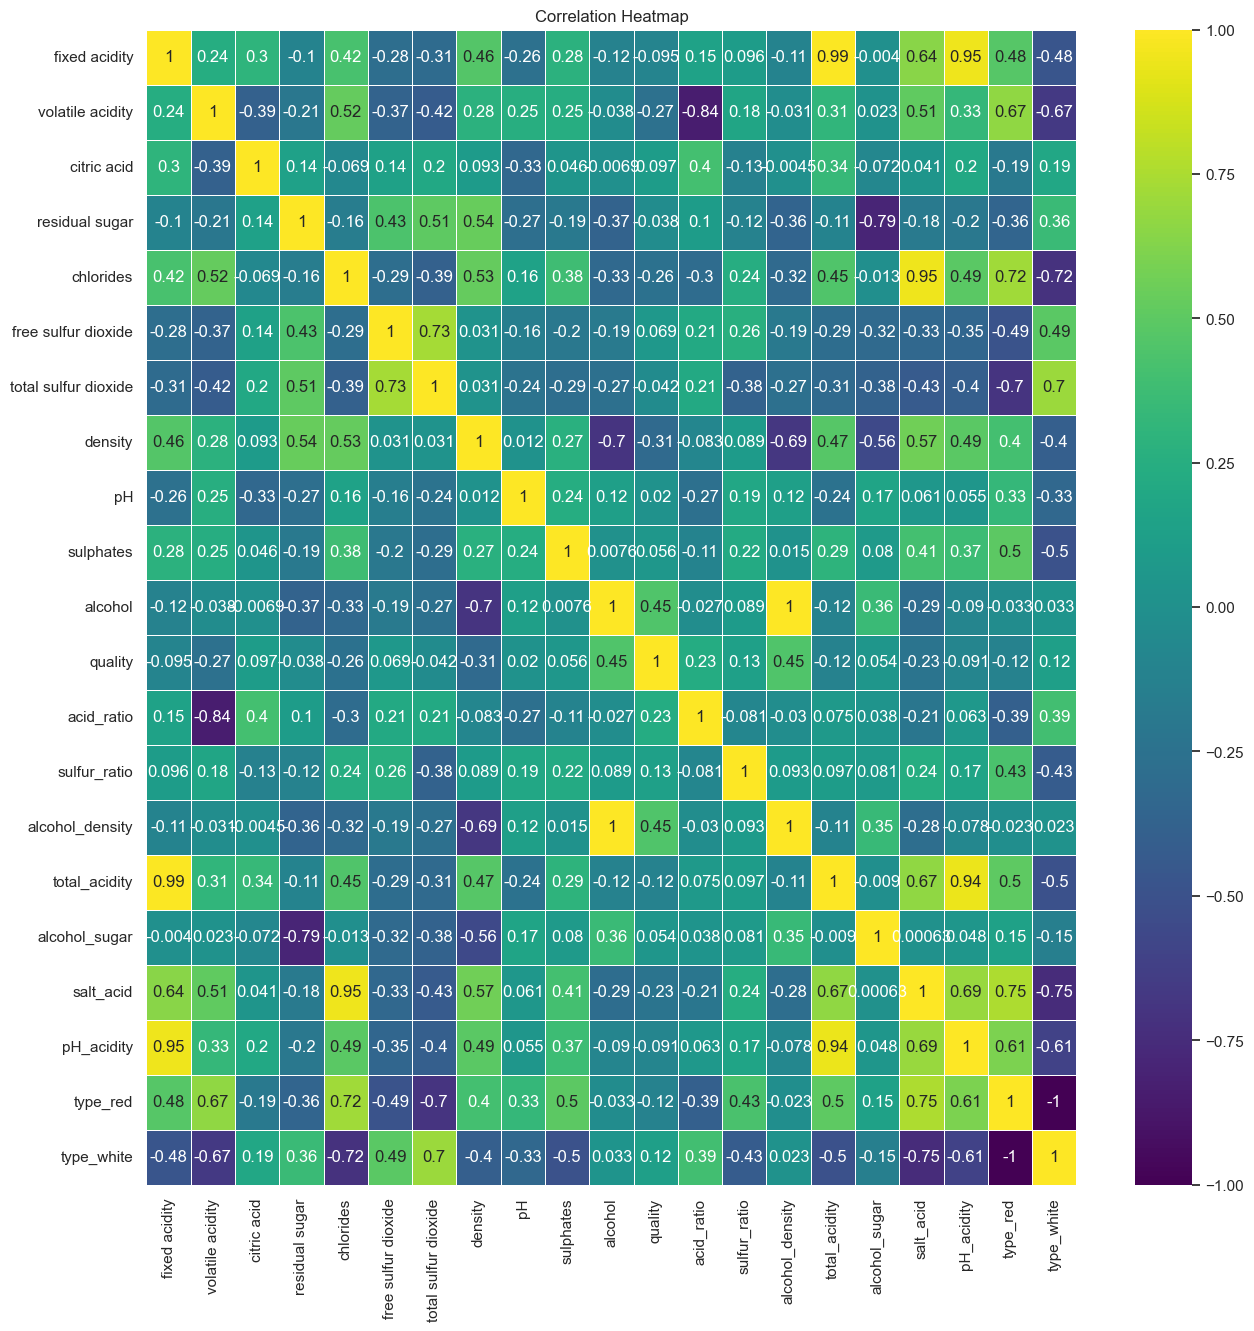

In [27]:
correlation = wine.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(correlation, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# `Feature Selection and Data Splitting`

In [28]:
X = wine.drop(columns=['quality'], axis=1)
y = wine['quality']

In [29]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,acid_ratio,sulfur_ratio,alcohol_density,total_acidity,alcohol_sugar,salt_acid,pH_acidity,type_red,type_white
0,7.0,0.27,0.36,17.55,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,25.925926,0.264706,8.80880,7.63,0.425121,0.3150,21.000,0,1
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,21.000000,0.106061,9.44300,6.94,5.937500,0.3087,20.790,0,1
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,28.928571,0.309278,10.05051,8.78,1.463768,0.4050,26.406,0,1
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,31.304348,0.252688,9.85644,7.75,1.164706,0.4176,22.968,0,1
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,31.304348,0.252688,9.85644,7.75,1.164706,0.4176,22.968,0,1


In [30]:
y.head()

0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
Name: quality, dtype: float64

# `Train Test Split`

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# `Model Training, Prediction and Evaluation`

## `Linear Regression`

Using `lr` within a pipeline for feature scaling 

In [32]:
pipe = Pipeline([
  ('scaler', StandardScaler()),
  ('model', LinearRegression())  
])

In [33]:
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
print(y_pred)

[6.3438343  6.08984277 5.95963903 ... 5.50064688 5.66661583 5.41882182]


#### Evaluation and Cross Validation

In [34]:
print('Train Model Score: ', pipe.score(X_train, y_train))
print('Test Model Score: ', pipe.score(X_test, y_test))

Train Model Score:  0.3155177066563277
Test Model Score:  0.3543575199427501


In [35]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline Linear Regression: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline Linear Regression: MAE=0.53, RMSE=0.65, R2=0.35


In [36]:
pipe_cv_scores = cross_val_score(pipe, wine, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'Pipeline CV RMSE:  {np.sqrt(-pipe_cv_scores).mean():.2f} +- {np.sqrt(-pipe_cv_scores).std():.2f}')

Pipeline CV RMSE:  0.00 +- 0.00


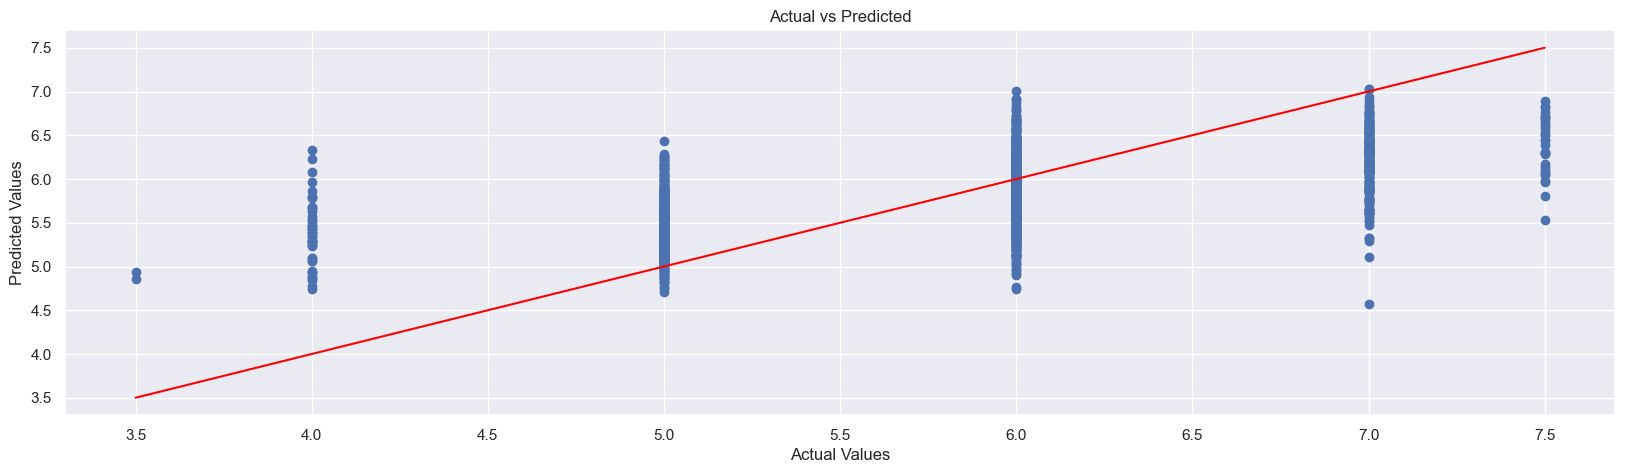

In [37]:
y_pred = pipe.predict(X_test)

plt.figure(figsize=(20, 5))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted")
plt.show()

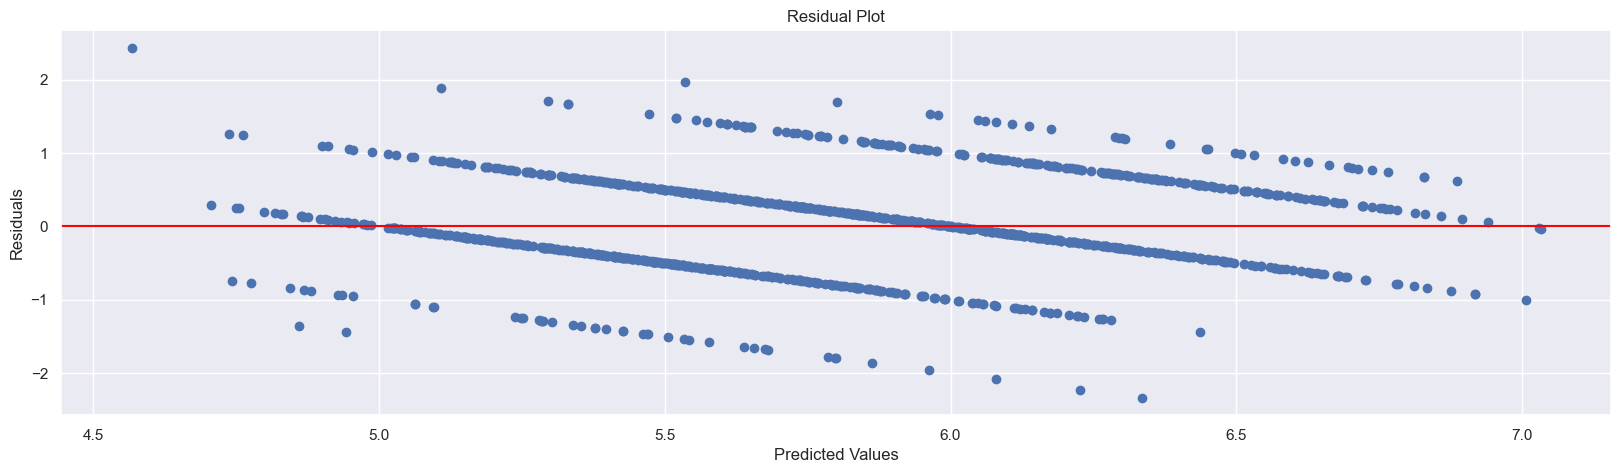

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(20, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.show()

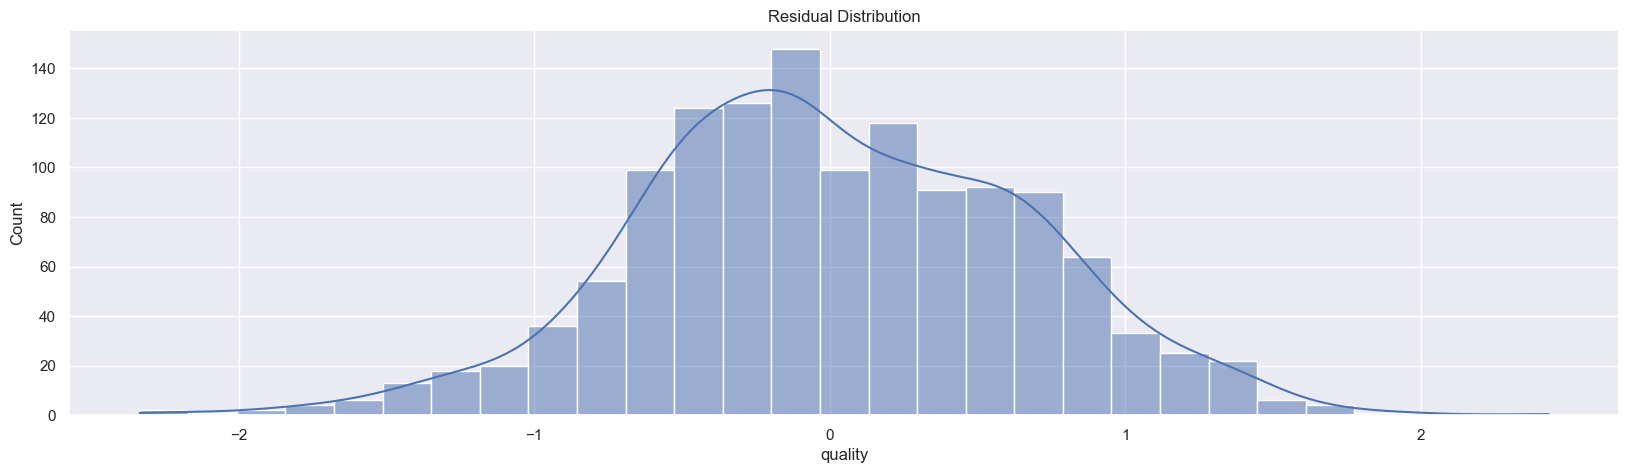

In [39]:
plt.figure(figsize=(20, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## `RandomForest Regressor`

In [40]:
rfr = RandomForestRegressor(n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)

rfr.fit(X_train, y_train)

y_pred = rfr.predict(X_train)
print(y_pred)

[5.45809998 5.46523646 5.64137381 ... 5.73676597 6.67401688 6.03730101]


#### Evaluation and Cross Validation

In [41]:
print('Train Model Score: ', rfr.score(X_train, y_train))
print('Test Model Score: ', rfr.score(X_test, y_test))

Train Model Score:  0.5348722115830331
Test Model Score:  0.441112155355565


In [42]:
y_pred = rfr.predict(X_test)
print(y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline RandomForest Regressor: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

[6.39765041 6.05248414 5.86227779 ... 5.36258944 5.8002436  5.50233543]
Baseline RandomForest Regressor: MAE=0.53, RMSE=0.61, R2=0.44


In [43]:
rfr_cv_scores = cross_val_score(rfr, wine, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'RandomForest CV RMSE:  {np.sqrt(-rfr_cv_scores).mean():.2f} +- {np.sqrt(-rfr_cv_scores).std():.2f}')

RandomForest CV RMSE:  0.26 +- 0.03


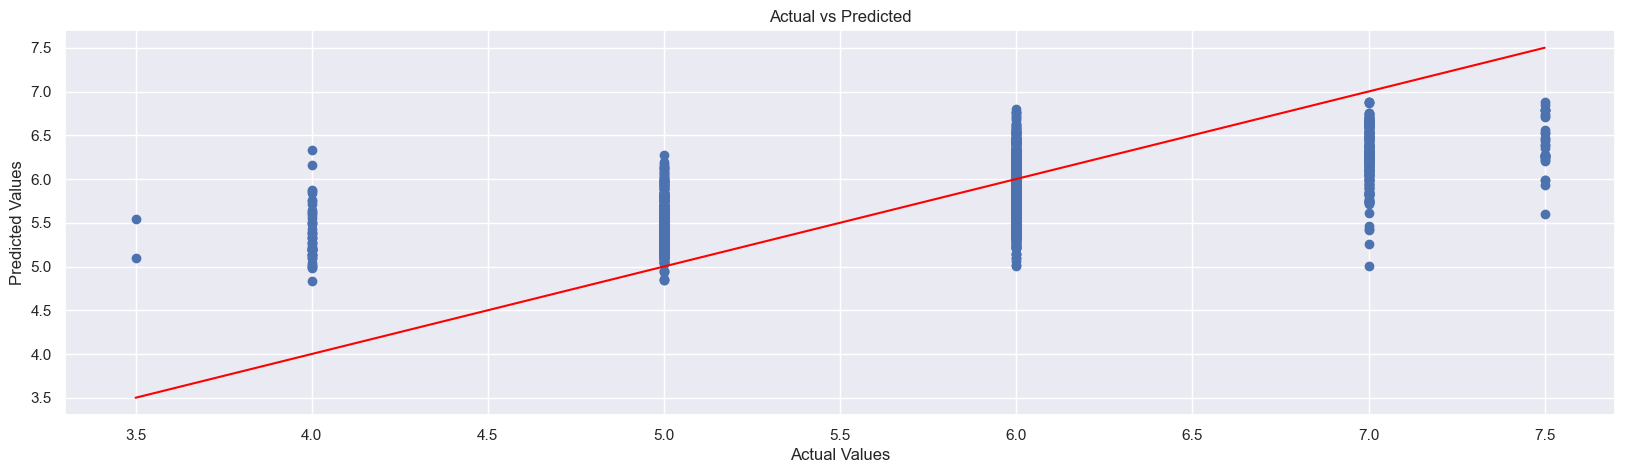

In [44]:
plt.figure(figsize=(20, 5))

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted")
plt.show()

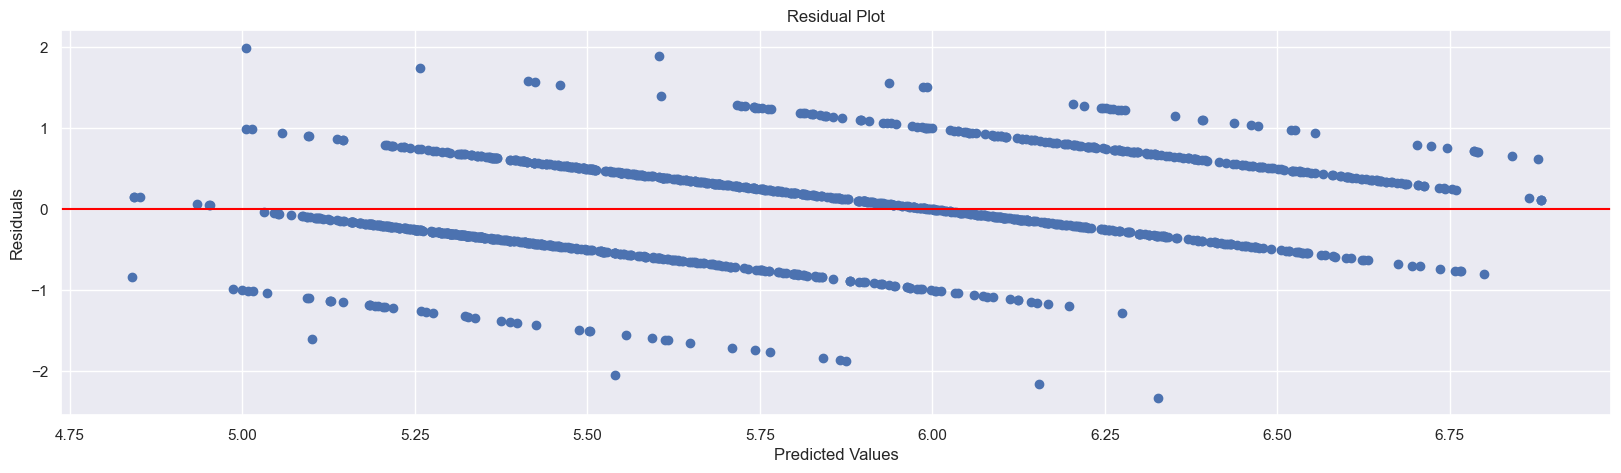

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(20, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.show()

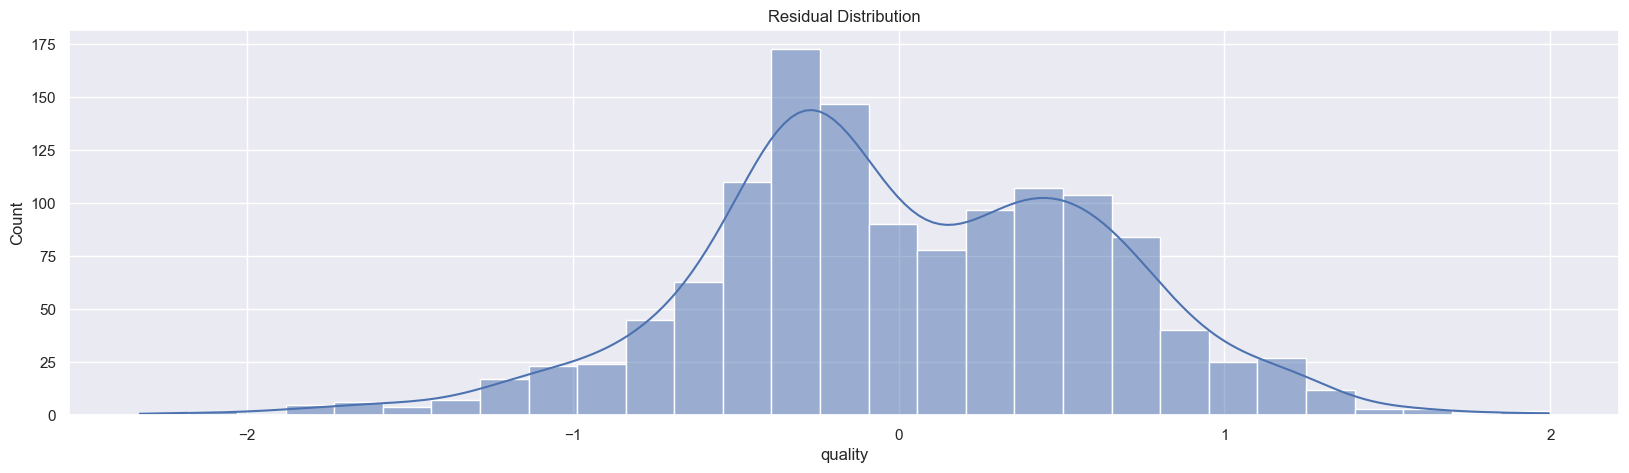

In [46]:
plt.figure(figsize=(20, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## `XGBRegressor`

In [47]:
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
print(y_pred)

[6.848844  6.1068907 5.877687  ... 5.4007773 5.8113627 6.0707173]


#### Evaluation and Cross Validation

In [48]:
print('Train Model Score: ', xgb.score(X_train, y_train))
print('Test Model Score: ', xgb.score(X_test, y_test))

Train Model Score:  0.929117428847916
Test Model Score:  0.5300570843518451


In [49]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline XGBRegressor: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline XGBRegressor: MAE=0.41, RMSE=0.56, R2=0.53


In [50]:
xgb_cv_scores = cross_val_score(xgb, wine, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'XGBRegressor CV RMSE:  {np.sqrt(-xgb_cv_scores).mean():.2f} +- {np.sqrt(-xgb_cv_scores).std():.2f}')

XGBRegressor CV RMSE:  0.00 +- 0.00


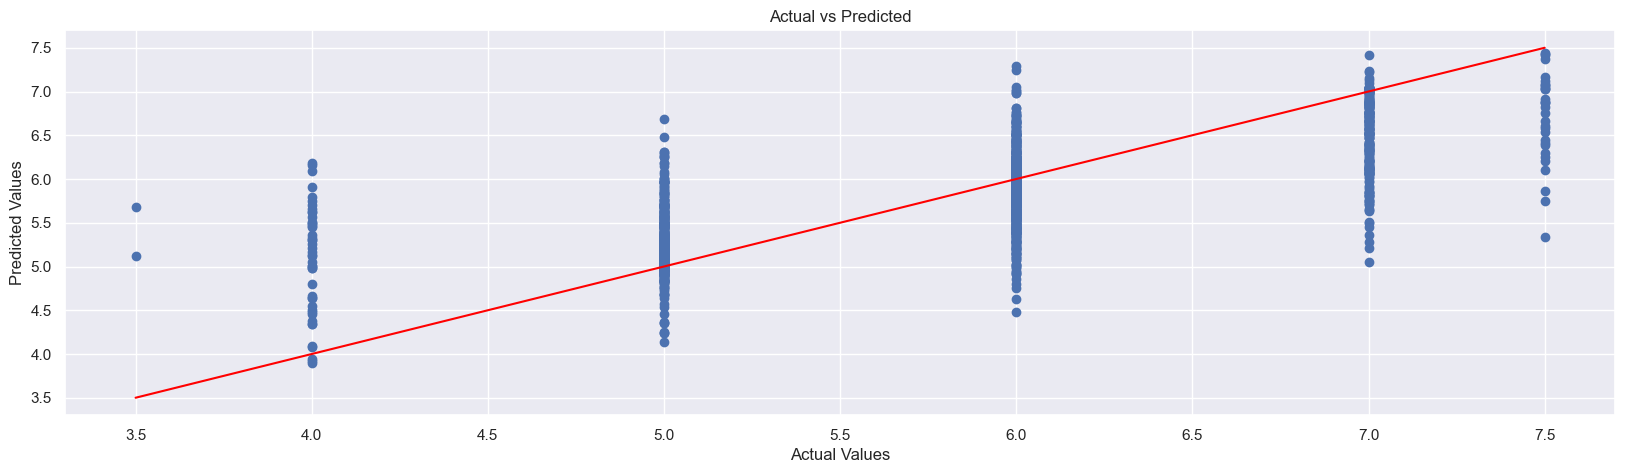

In [51]:
plt.figure(figsize=(20, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted")
plt.show()

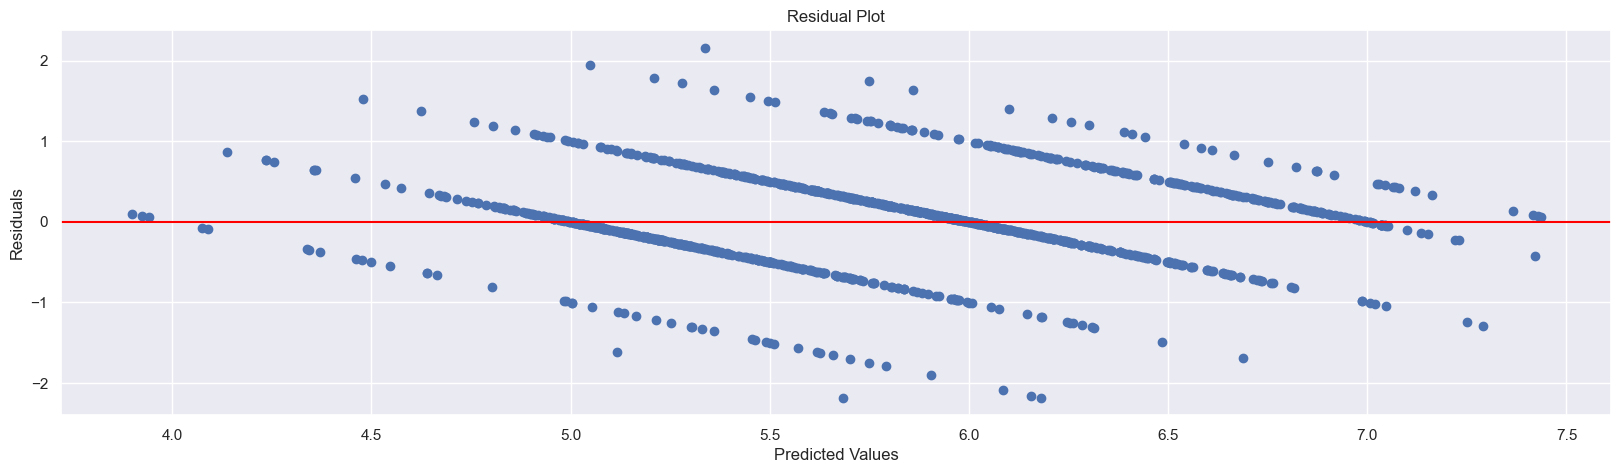

In [52]:
residuals = y_test - y_pred

plt.figure(figsize=(20, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")
plt.show()

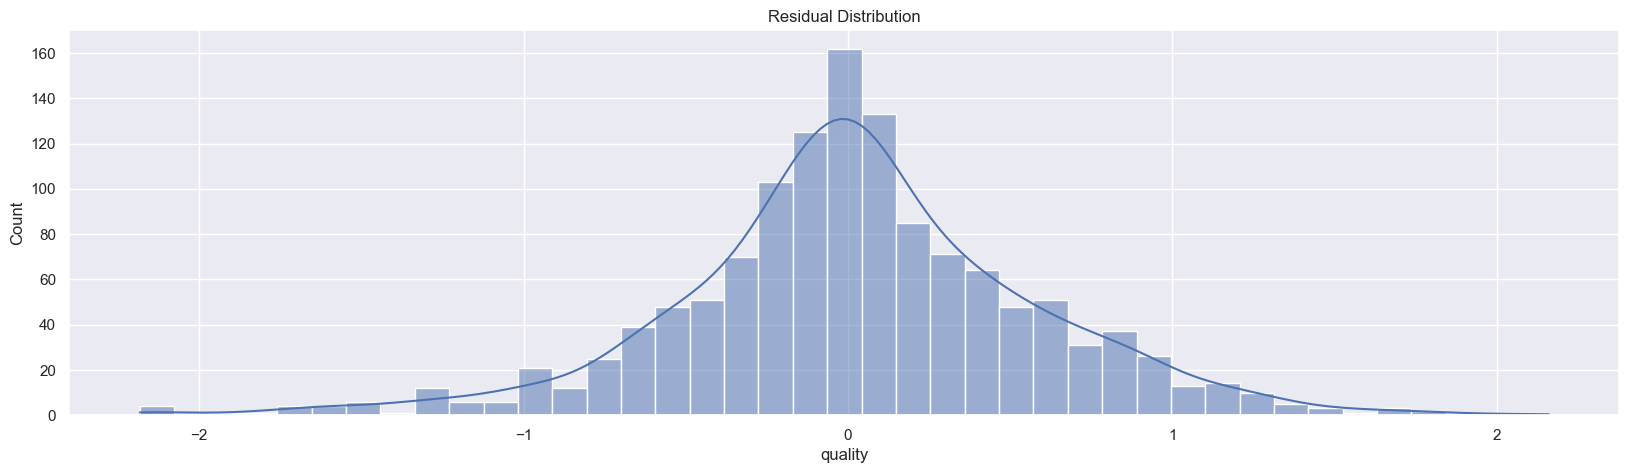

In [53]:
plt.figure(figsize=(20, 5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()